**Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs.**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def kernel(point, X, k):
    diff = X - point
    weights = np.exp(np.sum(diff**2, axis=1) / (-2 * k**2))
    return np.diag(weights)


def local_weight(point, X, y, k):
    W = kernel(point, X, k)
    return np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)


def lwlr(X, y, k):
    y_pred = np.zeros(X.shape[0])
    for i, point in enumerate(X):
        theta = local_weight(point, X, y, k)
        y_pred[i] = point @ theta
    return y_pred

In [14]:
# Load data
data = pd.read_csv("tips.csv")
X_raw = data["total_bill"].values
y = data["tip"].values.reshape(-1, 1)

# Add bias term
X = np.c_[np.ones(X_raw.shape[0]), X_raw]

# Predict
y_pred = lwlr(X, y, k=0.5).flatten()

/tmp/ipykernel_2935/2296285120.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i] = point @ theta


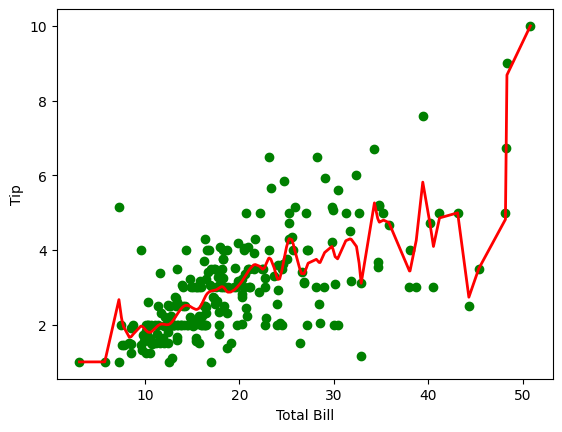

In [15]:
# Sort for plotting
sorted_idx = X[:, 1].argsort()

# Plot
plt.scatter(X_raw, y, color="green")
plt.plot(X[sorted_idx, 1], y_pred[sorted_idx], color="red", linewidth=2)
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()